In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rose.data import training_data
from rose.viz import plot_prediction_scatter

In [12]:
X_train, y_train = training_data(N=1_000, seed=37)

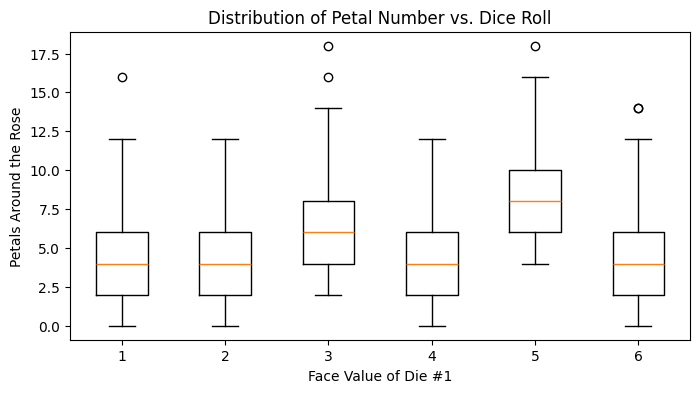

In [13]:
def plot_boxplot_by_die_value(X, y, i):
    df = pd.DataFrame({
        "die_value": X[:, i],
        "y": y,
    })

    die_values = np.sort(df["die_value"].unique())
    grouped_y = [df.loc[df["die_value"] == value, "y"].to_numpy() for value in die_values]

    plt.figure(figsize=(8, 4))
    plt.boxplot(grouped_y, tick_labels=[str(value) for value in die_values])
    plt.title(f"Distribution of Petal Number vs. Dice Roll")
    plt.xlabel(f"Face Value of Die #{i+1}")
    plt.ylabel("Petals Around the Rose")

plot_boxplot_by_die_value(X_train, y_train, 0)

Text(0.5, 1.0, 'Dice Rolls vs. Petals')

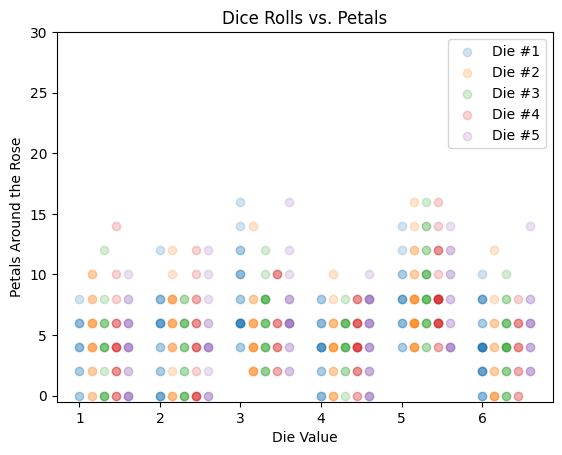

In [14]:
for index in range(X_train.shape[1]):
    plt.scatter(X_train[:100, index] + 0.15*index, y_train[:100], alpha=0.2, label=f"Die #{index+1}")
plt.ylim(-0.5, 30)
plt.legend()
plt.ylabel("Petals Around the Rose")
plt.xlabel("Die Value")
plt.title("Dice Rolls vs. Petals")

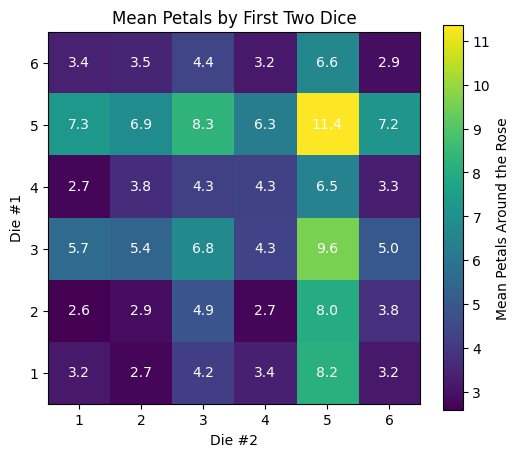

In [16]:
df = pd.DataFrame({
    "die_1": X_train[:, 0],
    "die_2": X_train[:, 1],
    "y": y_train,
})

mean_grid = (
    df.groupby(["die_1", "die_2"], as_index=False)["y"]
    .mean()
    .pivot(index="die_1", columns="die_2", values="y")
    .reindex(index=range(1, 7), columns=range(1, 7))
)

plt.figure(figsize=(6, 5))
image = plt.imshow(mean_grid.to_numpy(), origin="lower", cmap="viridis")
plt.colorbar(image, label="Mean Petals Around the Rose")

for row_index, die_1 in enumerate(mean_grid.index):
    for col_index, die_2 in enumerate(mean_grid.columns):
        value = mean_grid.loc[die_1, die_2]
        plt.text(col_index, row_index, f"{value:.1f}", ha="center", va="center", color="white")

plt.xticks(range(6), mean_grid.columns)
plt.yticks(range(6), mean_grid.index)
plt.xlabel("Die #2")
plt.ylabel("Die #1")
plt.title("Mean Petals by First Two Dice")
plt.show()